In [1]:
%pip install -q otter-grader

/Users/etowner/miniconda3/envs/cs701/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


# In-Class Exercise 06: Gaussian Mixture Models and EM

**DS701 — Session 7 (Mon Sep 28, 2026) — Section A1**

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/class_activity_notebooks/06-InClass-Exercise-GMM-EM-A1/06-InClass-Exercise-GMM-EM-A1.ipynb)

**Time: ~60 minutes.** Work in groups of 2-3.

Parts marked **(autograded)** are submitted to Gradescope; open-ended parts are graded
for participation. You may use AI assistance, but you must be able to explain and
justify every part of your solution when asked.

**Plan**

| Part | Topic | Grading | Time |
|---|---|---|---|
| 1 | The E-step and the M-step, by hand (1-D, two components) | autograded | ~20 min |
| 2 | Iterate to convergence, track the log-likelihood, check against `sklearn` | autograded | ~12 min |
| 3 | **Stretch:** soft vs. hard assignment in 2-D — responsibilities, covariance shapes, the 50/50 point | partly autograded | ~22 min |
| 4 | Wrap-up: when GMM, and what the log-likelihood curve tells you | participation | ~6 min |

Dependencies: `numpy`, `scipy`, `matplotlib`, `scikit-learn`.


## Setup

Part 1-2 use a **1-D** dataset: 500 numbers drawn from a two-component Gaussian mixture.

The generating story is exactly the one from the lecture: for each point, first pick a
component $k$ with probability $\pi_k$, then draw $x \sim \mathcal{N}(\mu_k, \sigma_k^2)$.
We keep the true labels `z_true` **only** to peek at the end; EM never sees them.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score


In [3]:
# Lecture section. Only A1 runs this semester; this is kept because the build
# script reads it to name the variant directory the notebook is published in.
SECTION = "A1"
SEED = 701
rng = np.random.default_rng(SEED)


In [4]:
# Colab: fetch the autograder tests for this activity.
import os, sys, urllib.request

if "google.colab" in sys.modules:
    os.makedirs("tests", exist_ok=True)
    BASE = "https://raw.githubusercontent.com/tools4ds/DS701-Materials-FA26/main/class_activity_notebooks/06-InClass-Exercise-GMM-EM-A1/tests/"
    for _q in ("q1", "q2", "q3", "q4", "q5", "q6", "q7"):
        urllib.request.urlretrieve(BASE + _q + ".py", "tests/" + _q + ".py")


In [5]:
# Initialize Otter
import otter
grader = otter.Notebook()

Section A1: n = 500 points, x ranges from -4.31 to 7.16


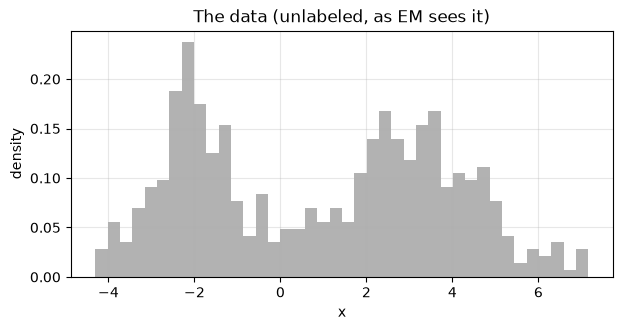

In [6]:
# --- 1-D two-component mixture (Parts 1-2) --------------------------------
TRUE = dict(mu=(-2.0, 3.0), sigma=(1.0, 1.5), pi=(0.4, 0.6))

n = 500
z_true = rng.choice(2, size=n, p=TRUE["pi"])                       # step 1: pick a component
x = rng.normal(np.array(TRUE["mu"])[z_true], np.array(TRUE["sigma"])[z_true])  # step 2: draw from it

print(f"Section {SECTION}: n = {n} points, x ranges from {x.min():.2f} to {x.max():.2f}")

plt.figure(figsize=(7, 3.2))
plt.hist(x, bins=40, density=True, color="gray", alpha=0.6)
plt.title("The data (unlabeled, as EM sees it)")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(alpha=0.3)
plt.show()


In [7]:
# A fixed, deliberately mediocre initialization -- everyone starts here so that
# intermediate results are comparable (and gradeable). Both means sit near the
# middle of the data; EM has to pull them apart.
mu0 = np.array([0.0, 1.0])
sigma0 = np.array([1.0, 1.0])
pi0 = np.array([0.5, 0.5])


## Part 1 (autograded): the E-step and the M-step, by hand

Recall the algorithm for a $K$-component mixture with parameters
$\theta = \{\pi_k, \mu_k, \sigma_k\}$:

- **E-step** — for every point $i$ and component $k$, the *responsibility* is Bayes' rule
  with the mixing weights as priors and the Gaussian densities as likelihoods:

  $$\gamma_{ik} = \frac{\pi_k\, \mathcal{N}(x_i \mid \mu_k, \sigma_k^2)}
                       {\sum_{j=1}^{K} \pi_j\, \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)} .$$

- **M-step** — with $N_k = \sum_i \gamma_{ik}$, the *weighted* MLE formulas from lecture 05:

  $$\mu_k = \frac{1}{N_k}\sum_i \gamma_{ik}\, x_i, \qquad
    \sigma_k^2 = \frac{1}{N_k}\sum_i \gamma_{ik}\,(x_i - \mu_k)^2, \qquad
    \pi_k = \frac{N_k}{n} .$$

The lecture's *Watch It Run* slides showed these as three short functions on the age data.
Write them here, on new data, before you look back.

### 1a. The E-step

**Task.** Implement `e_step(x, mu, sigma, pi)` with `numpy` and `scipy.stats.norm.pdf`.
Do **not** call `sklearn` here — the point is to know exactly what the library is doing.

- Inputs: `x` of shape `(n,)`; `mu`, `sigma`, `pi` each of shape `(K,)`
  (`sigma` is the standard deviation, not the variance).
- Output: `gamma`, an array of shape `(n, K)` whose row $i$ holds $\gamma_{i1}, \dots, \gamma_{iK}$.
  Every row must sum to 1.

Hint: `norm.pdf(x[:, None], loc=mu[None, :], scale=sigma[None, :])` broadcasts to an
`(n, K)` array of densities in one line.


In [ ]:
def e_step(x, mu, sigma, pi):
    """Return the (n, K) matrix of responsibilities gamma[i, k] = P(z_i = k | x_i, theta)."""
    p_k = pi * norm.pdf(x[:, None], loc=mu[None, :], scale=sigma[None, :])  
    p_x = np.sum(p_k, axis=1, keepdims=True)  
    return p_k / p_x[:, None]  


gamma0 = e_step(x, mu0, sigma0, pi0)
print("gamma0.shape =", gamma0.shape)
print("first five rows:\n", np.round(gamma0[:5], 3))


gamma0.shape = (500, 2)
first five rows:
 [[0.06  0.94 ]
 [0.022 0.978]
 [0.086 0.914]
 [0.039 0.961]
 [0.551 0.449]]


In [9]:
grader.check("q1")

q1 results: All test cases passed!

### 1b. The M-step

**Task.** Implement `m_step(x, gamma)` returning the tuple `(mu, sigma, pi)`, each an array of
shape `(K,)`, using the weighted formulas above. Return the standard deviation `sigma`
(take the square root of the weighted variance).

Then run **one** E-step from the initial parameters followed by **one** M-step and store the
result in `mu1, sigma1, pi1`.


In [21]:
def m_step(x, gamma):
    """Weighted MLE update. Returns (mu, sigma, pi), each of shape (K,)."""
    N = np.sum(gamma, axis=0)
    x_n = x[:, None]
    mu = np.sum(gamma * x_n, axis=0) / N
    s = np.sqrt(np.sum(gamma * (x_n - mu[None,:])**2, axis=0) / N)
    pi = N / len(x)
    return (mu, s, pi)

mu0 = np.array([0.0, 1.0])
sigma0 = np.array([1.0, 1.0])
pi0 = np.array([0.5, 0.5])
gamma0 = e_step(x, mu0, sigma0, pi0)
mu1, sigma1, pi1 = m_step(x, gamma0)
print("after one EM iteration:")
print("  mu    =", np.round(mu1, 3))
print("  sigma =", np.round(sigma1, 3))
print("  pi    =", np.round(pi1, 3))


after one EM iteration:
  mu    = [-1.532  2.988]
  sigma = [1.67  1.901]
  pi    = [0.461 0.539]


In [22]:
grader.check("q2")

q2 results: All test cases passed!

## Part 2 (autograded): iterate, track the log-likelihood, and check against `scikit-learn`

The quantity EM is climbing is the **log-likelihood of the observed data**,

$$\ell(\theta) = \sum_{i=1}^{n} \log \Big( \sum_{k=1}^{K} \pi_k\, \mathcal{N}(x_i \mid \mu_k, \sigma_k^2) \Big),$$

the sum-inside-the-log that has no closed-form maximizer — which is why we iterate.

**Task.**

1. Implement `log_likelihood(x, mu, sigma, pi)` returning a single `float`.
2. Implement `run_em(x, mu, sigma, pi, max_iter=200, tol=1e-6)` returning
   `(mu, sigma, pi, loglik_history)`, where `loglik_history` is a Python list whose
   entry 0 is $\ell$ at the initial parameters and entry $t$ is $\ell$ after
   iteration $t$. Stop when the improvement in $\ell$ falls below `tol`, or after
   `max_iter` iterations.
3. Run it from `mu0, sigma0, pi0` and store the results in `mu_hat, sigma_hat, pi_hat, loglik_hist`.


In [28]:
def log_likelihood(x, mu, sigma, pi):
    """Observed-data log-likelihood of the mixture, as a float."""
    inner = np.sum(pi * norm.pdf(x[:, None], loc=mu[None, :], scale=sigma[None, :]), axis=1)
    return np.sum(np.log(inner))


def run_em(x, mu, sigma, pi, max_iter=200, tol=1e-6):
    """Alternate E- and M-steps. Returns (mu, sigma, pi, loglik_history)."""
    loglik_hist = [log_likelihood(x, mu, sigma, pi)]
    for i in range(max_iter):
        gamma = e_step(x, mu, sigma, pi)
        mu, sigma, pi = m_step(x, gamma)
        loglik_hist.append(log_likelihood(x, mu, sigma, pi))
        if abs(loglik_hist[-1] - loglik_hist[-2]) < tol:
            break
    return mu, sigma, pi, loglik_hist

mu_hat, sigma_hat, pi_hat, loglik_hist = run_em(x, mu0, sigma0, pi0)
print(f"converged after {len(loglik_hist) - 1} iterations")
print("  mu    =", np.round(mu_hat, 3), "   (true:", TRUE["mu"], ")")
print("  sigma =", np.round(sigma_hat, 3), "   (true:", TRUE["sigma"], ")")
print("  pi    =", np.round(pi_hat, 3), "   (true:", TRUE["pi"], ")")
print(f"  log-likelihood: {loglik_hist[0]:.1f} -> {loglik_hist[-1]:.1f}")


converged after 28 iterations
  mu    = [-2.088  3.033]    (true: (-2.0, 3.0) )
  sigma = [0.933 1.645]    (true: (1.0, 1.5) )
  pi    = [0.416 0.584]    (true: (0.4, 0.6) )
  log-likelihood: -2270.9 -> -1146.6


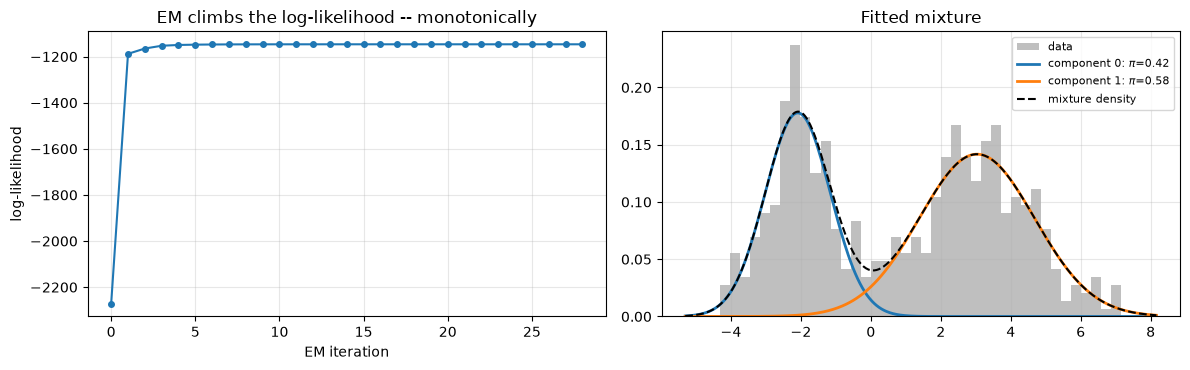

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].plot(loglik_hist, "o-", markersize=4)
axes[0].set_xlabel("EM iteration")
axes[0].set_ylabel("log-likelihood")
axes[0].set_title("EM climbs the log-likelihood -- monotonically")
axes[0].grid(alpha=0.3)

grid = np.linspace(x.min() - 1, x.max() + 1, 400)
axes[1].hist(x, bins=40, density=True, color="gray", alpha=0.5, label="data")
for k in range(2):
    axes[1].plot(grid, pi_hat[k] * norm.pdf(grid, mu_hat[k], sigma_hat[k]),
                 lw=2, label=f"component {k}: $\\pi$={pi_hat[k]:.2f}")
axes[1].plot(grid, sum(pi_hat[k] * norm.pdf(grid, mu_hat[k], sigma_hat[k]) for k in range(2)),
             "k--", lw=1.5, label="mixture density")
axes[1].set_title("Fitted mixture")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [30]:
grader.check("q3")

q3 results: All test cases passed!

### 2b. Check against `scikit-learn`

**Task.** Fit `sklearn.mixture.GaussianMixture` on the same data from the **same** starting
point and store the fitted object in `gm1`. `sklearn` wants a 2-D array of shape `(n, 1)`,
means of shape `(K, 1)`, and *precisions* ($1/\sigma^2$) of shape `(K, 1, 1)`:

```python
gm1 = GaussianMixture(
    n_components=2,
    means_init=mu0.reshape(-1, 1),
    weights_init=pi0,
    precisions_init=(1 / sigma0**2).reshape(-1, 1, 1),
    tol=1e-6, max_iter=500, random_state=SEED,
).fit(x.reshape(-1, 1))
```

Then compare `gm1.means_.ravel()`, `np.sqrt(gm1.covariances_.ravel())`, and `gm1.weights_`
with your `mu_hat`, `sigma_hat`, `pi_hat`. They should agree to two or three decimals —
`sklearn` uses a slightly different stopping rule and a tiny covariance regularizer, so
they will not be bit-identical.


In [31]:
gm1 = GaussianMixture(n_components=2, 
                     means_init=mu0.reshape(-1,1), 
                     weights_init=pi0, 
                     precisions_init= (1 /sigma0**2).reshape(-1,1,1),
                     tol=1e-6, max_iter=500, random_state=SEED).fit(x.reshape(-1, 1))
print("mine:    mu =", np.round(mu_hat, 3), " sigma =", np.round(sigma_hat, 3), " pi =", np.round(pi_hat, 3))
print("sklearn: mu =", np.round(gm1.means_.ravel(), 3), " sigma =", np.round(np.sqrt(gm1.covariances_.ravel()), 3),
      " pi =", np.round(gm1.weights_, 3))
print(f"sklearn total log-likelihood: {gm1.score(x.reshape(-1, 1)) * len(x):.1f}   mine: {loglik_hist[-1]:.1f}")


mine:    mu = [-2.088  3.033]  sigma = [0.933 1.645]  pi = [0.416 0.584]
sklearn: mu = [-2.087  3.034]  sigma = [0.934 1.644]  pi = [0.416 0.584]
sklearn total log-likelihood: -1146.6   mine: -1146.6


In [32]:
grader.check("q4")

q4 results: All test cases passed!

Peek, only now, at how well the *soft* labels line up with the true generating component
(a responsibility above 0.5 means "mostly component 1"):


In [33]:
gamma_hat = e_step(x, mu_hat, sigma_hat, pi_hat)
# Components can come out in either order; align by the smaller mean.
lo = int(np.argmin(mu_hat))
hard = (gamma_hat[:, lo] < 0.5).astype(int)          # 0 = "mostly the low component"
print("agreement with the true component:", np.mean(hard == z_true).round(3))
print("points with max responsibility below 0.9:", int((gamma_hat.max(axis=1) < 0.9).sum()), "of", n)


agreement with the true component: 0.974
points with max responsibility below 0.9: 34 of 500


## Part 3 — Stretch (partly autograded): soft vs. hard assignment, visualized

The lecture *told* you that GMM makes soft assignments and $k$-means makes hard ones. Here you
**see** what that buys. Below is a 2-D dataset of three **overlapping** blobs, one of them
stretched into an ellipse — each section gets its own layout. Fit $k$-means and a
full-covariance GMM on it, and look at three things:

1. the GMM's **responsibilities**, drawn as color intensity, next to $k$-means' hard, straight-edged boundaries;
2. how the fitted **ellipses** change with `covariance_type` (`spherical`, `diag`, `tied`, `full`);
3. one specific point whose responsibility is about **50/50**, and what $k$-means does with it.


In [ ]:
# --- 2-D overlapping blobs (Part 3) --------------------------------------
_centers = [[0.0, 0.0], [3.0, 2.5], [-0.5, 4.0]]
_stds = [1.0, 1.7, 0.7]
_sizes = [250, 250, 100]
_stretch = np.array([[1.4, 0.6], [0.0, 0.7]])

X2, y2 = make_blobs(n_samples=_sizes, centers=_centers, cluster_std=_stds, random_state=SEED)
# Stretch blob 1 into an ellipse (anisotropic), keeping its center in place.
X2 = np.where((y2 == 1)[:, None], (X2 - _centers[1]) @ _stretch + _centers[1], X2)

print("X2.shape =", X2.shape)
plt.figure(figsize=(5.5, 4.5))
plt.scatter(X2[:, 0], X2[:, 1], s=12, c="gray", alpha=0.7)
plt.title("Three overlapping blobs (unlabeled)")
plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)
plt.show()


### 3a (autograded): responsibilities vs. hard labels

**Task.**

1. Fit `km2 = KMeans(n_clusters=3, n_init=10, random_state=SEED)` on `X2`.
2. Fit `gm2 = GaussianMixture(n_components=3, covariance_type="full", random_state=SEED)` on `X2`.
3. Compute `resp = gm2.predict_proba(X2)` — the responsibility matrix, shape `(n, 3)` — and
   `max_resp = resp.max(axis=1)`, each point's largest responsibility.
4. Store in `n_uncertain` the number of points whose `max_resp` is below `0.6` (no
   component owns even 60% of them), and in `frac_uncertain` that count divided by `len(X2)`.
5. Store in `ari_km_gmm` the `adjusted_rand_score` between `km2.labels_` and
   `gm2.predict(X2)` — how much the two *hard* partitions agree (1.0 = identical).


In [ ]:
km2 = ...
gm2 = ...

...

print(f"points with no component above 60% responsibility: {n_uncertain} of {len(X2)} ({100*frac_uncertain:.1f}%)")
print(f"agreement of the two hard partitions (ARI): {ari_km_gmm:.3f}")


In [ ]:
# --- Visualize: k-means' hard boundaries vs. the GMM's responsibilities -----
def _grid(X, h=0.05):
    x0, x1 = X[:, 0].min() - 1, X[:, 0].max() + 1
    y0, y1 = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]

xx, yy, G = _grid(X2)
gm_hard = gm2.predict(X2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# (1) k-means: hard labels + Voronoi cells (straight edges).
axes[0].contourf(xx, yy, km2.predict(G).reshape(xx.shape), alpha=0.15, cmap="viridis")
axes[0].scatter(X2[:, 0], X2[:, 1], c=km2.labels_, cmap="viridis", s=12)
axes[0].scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1], c="red", marker="x", s=150, linewidths=3)
axes[0].set_title("k-means: hard assignment, straight boundaries")

# (2) GMM: argmax label as hue, max responsibility as intensity (faint = uncertain).
axes[1].contourf(xx, yy, gm2.predict(G).reshape(xx.shape), alpha=0.15, cmap="viridis")
axes[1].scatter(X2[:, 0], X2[:, 1], c=gm_hard, cmap="viridis", s=12, alpha=np.clip((max_resp - 1/3) / (2/3), 0.08, 1.0))
axes[1].scatter(gm2.means_[:, 0], gm2.means_[:, 1], c="red", marker="x", s=150, linewidths=3)
axes[1].set_title("GMM: color intensity = max responsibility")

# (3) The uncertain points, isolated.
axes[2].scatter(X2[:, 0], X2[:, 1], c="lightgray", s=10)
sc = axes[2].scatter(X2[max_resp < 0.6, 0], X2[max_resp < 0.6, 1], c=max_resp[max_resp < 0.6], cmap="magma", s=28, vmin=1/3, vmax=0.6)
plt.colorbar(sc, ax=axes[2], label="max responsibility")
axes[2].set_title(f"{n_uncertain} points no component owns (< 0.6)")

for ax in axes:
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Look before you move on (participation).** Where do the faint points live in the middle
panel? Are they where the $k$-means boundaries are? Write one sentence.

*(your answer here)*


In [ ]:
grader.check("q5")

### 3b (autograded): covariance shapes

A GMM's assumptions are explicit, and `covariance_type` is where you choose them:

| `covariance_type` | each component's $\Sigma_k$ | parameters (d = 2, K = 3) |
|---|---|---|
| `spherical` | $\sigma_k^2 I$ — a circle | 3 |
| `diag` | diagonal — an axis-aligned ellipse | 6 |
| `tied` | one shared full $\Sigma$ — same ellipse everywhere | 3 |
| `full` | its own full $\Sigma_k$ — any ellipse | 9 |

**Task.** For each of the four types, fit `GaussianMixture(n_components=3,
covariance_type=ct, random_state=SEED)` on `X2` and record

- `bic_by_cov[ct] = gm.bic(X2)` — the Bayesian Information Criterion (lower is better;
  it is $-2\ell$ plus a penalty for the number of parameters), and
- `ari_by_cov[ct] = adjusted_rand_score(y2, gm.predict(X2))` — agreement with the true blobs
  (peeking is allowed here; we are diagnosing).

Store the type with the lowest BIC in `best_cov`.


In [ ]:
COV_TYPES = ["spherical", "diag", "tied", "full"]
bic_by_cov, ari_by_cov, fits_by_cov = {}, {}, {}

...

for ct in COV_TYPES:
    print(f"{ct:10s}  BIC = {bic_by_cov[ct]:8.1f}   ARI vs truth = {ari_by_cov[ct]:.3f}")
print("lowest BIC:", best_cov)
print(f"(k-means, for reference: ARI vs truth = {adjusted_rand_score(y2, km2.labels_):.3f})")


In [ ]:
# --- Draw the fitted ellipses for each covariance type ---------------------
from matplotlib.patches import Ellipse


def draw_ellipse(ax, mean, cov, color, n_std=2.0):
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse(mean, w, h, angle=angle, fill=False, lw=2, color=color))


def cov_matrix(gm, k):
    """Return component k's covariance as a 2x2 matrix, whatever the covariance_type."""
    c = gm.covariances_
    if gm.covariance_type == "full":
        return c[k]
    if gm.covariance_type == "tied":
        return c
    if gm.covariance_type == "diag":
        return np.diag(c[k])
    return np.eye(2) * c[k]          # spherical


fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, ct in zip(axes, COV_TYPES):
    g = fits_by_cov.get(ct)
    if g is None:
        g = GaussianMixture(n_components=3, covariance_type=ct, random_state=SEED).fit(X2)
    lab = g.predict(X2)
    ax.scatter(X2[:, 0], X2[:, 1], c=lab, cmap="viridis", s=8, alpha=0.5)
    for k in range(3):
        draw_ellipse(ax, g.means_[k], cov_matrix(g, k), color=plt.cm.viridis(k / 2))
    ax.set_title(f"{ct}\nBIC = {g.bic(X2):.0f}")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
grader.check("q6")

### 3c (autograded): the 50/50 point

**Task.** Using `resp` and `max_resp` from 3a (the `full` model `gm2`):

- `idx_half` — the index of the point whose largest responsibility is **closest to 0.5**
  (i.e. minimizes `|max_resp - 0.5|`). This is the point the GMM is least sure about.
- `resp_half` — that point's row of `resp` (shape `(3,)`).
- `km_label_half` — the $k$-means label `km2.labels_[idx_half]`.

Then run the plotting cell and find the point on both panels.


In [ ]:
idx_half = ...
resp_half = ...
km_label_half = ...

print("point", idx_half, "at", np.round(X2[idx_half], 2))
print("GMM responsibilities:", np.round(resp_half, 3))
print("k-means says: cluster", km_label_half, "-- with 100% confidence, as always")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].contourf(xx, yy, km2.predict(G).reshape(xx.shape), alpha=0.15, cmap="viridis")
axes[0].scatter(X2[:, 0], X2[:, 1], c=km2.labels_, cmap="viridis", s=10, alpha=0.5)
axes[0].set_title(f"k-means: point {idx_half} -> cluster {km_label_half}")
axes[1].contourf(xx, yy, gm2.predict(G).reshape(xx.shape), alpha=0.15, cmap="viridis")
axes[1].scatter(X2[:, 0], X2[:, 1], c=gm_hard, cmap="viridis", s=10, alpha=np.clip((max_resp - 1/3) / (2/3), 0.08, 1.0))
axes[1].set_title("GMM: responsibilities " + str(np.round(resp_half, 2)))
for ax in axes:
    ax.scatter(*X2[idx_half], s=350, facecolors="none", edgecolors="red", linewidths=3)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
grader.check("q7")

<!-- BEGIN QUESTION -->

## Part 4 (open-ended, participation): when GMM, and what the curve says

Discuss in your group and write short answers. **Be ready to explain your reasoning when
staff visit your table** — they will ask you to point at your plots.

1. Look at your 50/50 point from 3c. What does $k$-means do with it, and what information is
   lost? Give one concrete downstream decision where that lost information would matter.
2. From your Part 3 plots and numbers (`ari_by_cov`, k-means' ARI, the ellipses): **when would
   you prefer a GMM over $k$-means, and when is $k$-means good enough?** Name at least one
   property of the data for each case.
3. Look at your log-likelihood curve from Part 2. What does its *shape* tell you about
   convergence — where did most of the progress happen, and why does the stopping rule use
   the *change* in $\ell$ rather than its value? Would a curve that briefly went *down*
   be a warning sign, and of what?


_Type your answer here, replacing this text._

<!-- END QUESTION -->

### If you have time

- Re-run Part 2 from a different `mu0` (say `[-5, 5]` or `[2, 2.5]`). Does EM reach the same
  log-likelihood? The same parameters? What happens with `[2, 2]` exactly?
- In Part 3, sweep `n_components` from 1 to 6 with `covariance_type="full"` and plot BIC.
  Where is the minimum, and how does that compare with the elbow/silhouette story for $k$-means?


In [ ]:
# Scratch space.


## Wrap-up

Before you leave, each group should be able to answer:

1. In one sentence each: what does the E-step compute, and what does the M-step compute?
2. Why can EM never decrease the log-likelihood — and why does that not make it find the global maximum?
3. Name one thing the GMM in Part 3 told you that $k$-means could not.

Submit the autograded parts (1a, 1b, 2, 2b, 3a, 3b, 3c) and your Part 4 answers to Gradescope.
